In [ ]:
#TODO
# SAM, MedSAM(fine-tuned decoder), SAMMed2D(fine-tuned all) results over 51 datasets

#### How can we fine tune SAM efficitively with the least data?  

1. Will different selection query give us diferent results?    
constraint:  
 dataset size:51 (40 train; 11 test)  
 epochs: 1000 for add one sample 
 fixed random seed  
 model: SAM  
 checkpoint: b  
 fine-tuning structure: mask decoder  

* baseline: random selection from 40 dataset
* entropy with dropout 
* entropy with dropout + artifacts
* encoder of SAM + clustering  



- Plot: Accuracy on the 11 test set as a function of number of selected samples (training)
- ID of selected samples for each iteration

In [1]:
import datasets.path as path
# import nibabel as nib
from glob import glob
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import monai
# from utils.SurfaceDice import compute_dice_coefficient
from tqdm import tqdm
import json
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
import matplotlib.pyplot as plt
import wandb
from utils import NpzDataset, save_preds_nii
from metrics import compute_dice_coefficient
from strategy import random_sampling
from eval import infer, log_image_table
import SimpleITK as sitk


In [2]:
# training and sampling dataset path prefix
prefix = './datasets/RAINE_organ_51'
task = 'MRI_LeftKidney'
training_pool_path = os.path.join(prefix, task, 'train')
# label id
# left kidney: 1,
# right kidney: 2,
# pancreas: 3,
# background: 0,
label_id = 1

#SAM MODEL TYPE 
sam_model_type = 'vit_b'
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# sample strategy
strategy = 'random'
# active learning fine tunning checkpoint
base_model = 'SAM'
save_path_ckp = os.path.join('./checkpoints/', base_model + '_' + task + '_' + strategy)
os.makedirs(save_path_ckp, exist_ok=True)
# sampling dataset path
sampling_datapath = os.path.join(prefix, task, base_model+'_sampling')
os.makedirs(sampling_datapath, exist_ok=True)

In [3]:
training_pool = glob(os.path.join(training_pool_path, '*.npz'))
sample_pool = []
num_epochs = 150
batch_size = 16 # make sure batch size is smaller than sample slices
losses = []
best_loss = 1e10
sam_model = sam_model_registry[sam_model_type](checkpoint=checkpoint).to(device)

# Set up the optimizer, hyperparameter tuning will improve performance here
optimizer = torch.optim.Adam(sam_model.mask_decoder.parameters(), lr=1e-5, weight_decay=0)
seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

save_path_ckp_epoch = os.path.join(save_path_ckp, f'epochs{num_epochs}')
os.makedirs(save_path_ckp_epoch, exist_ok=True)

# wandb
# wandb.init(
#     # Set the project where this run will be logged
#     project="SAM-Activelearning", 
#     group="random",
#     name=f'{base_model}_{sam_model_type}_{task}_{strategy}_epoch{num_epochs}',
#     config = {
#         "task": task,
#         'label_id': label_id,
#         'base_model': base_model,
#         "model": sam_model_type,
#         "strategy": strategy,
#         "num_epochs": num_epochs
#     }
# )


In [ ]:
# !export WANDB_BASE_URL=http://172.17.0.1:8080
# !export WANDB_API_KEY=4aaa2e71cdec13a78a42c6ceac38dd0c7235a131

# wandb.login()

In [4]:
# eval training pool
training_pool = glob(os.path.join(training_pool_path, '*.npz'))
dice_train = []
original_shape = (124, 234, 288)
num_epochs = 100
ckp_paths = sorted(glob(os.path.join(save_path_ckp, f'epochs{num_epochs}', '*latest.pth')))
for p in tqdm(ckp_paths):
    if '40' in p:
        avg_dice = []
        for t in tqdm(training_pool):
            id = os.path.basename(t).split('.')[0]
            print('id', id)
            imgs = np.load(t)['imgs']

            dataset = NpzDataset([t])
            batch_size = len(dataset)
            dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
            for embeddings, gts, _ in dataloader:
                preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
            print(preds.shape, type(preds))

            gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
            print(gts.shape, type(gts))
            break
    #     break
    # break   
    #     dice = compute_dice_coefficient(gts, preds)
    #     avg_dice.append(dice)
    # dice_train.append(np.mean(avg_dice))

# plt.plot(dice_train)
# plt.xlabel('Number of samples')
# plt.ylabel('Dice coefficient')
# plt.title(f'{base_model} {task} {strategy} sampling')
# # plt.show()
# plt.savefig(os.path.join('figures/train', f'{base_model}_{task}_{strategy}_epochs{num_epochs}_sampling.png'))
# plt.close()

  0%|          | 0/40 [00:00<?, ?it/s]

id sub-50890


100%|██████████| 40/40 [00:03<00:00, 10.48it/s]

(41, 256, 256) <class 'numpy.ndarray'>
(41, 256, 256) <class 'numpy.ndarray'>


In [9]:
save_path = os.path.join('datasets/predictions', f'{task}_{base_model}_{sam_model_type}_{strategy}')
os.makedirs(save_path, exist_ok=True)
ori_zeros, img_array = save_preds_nii(id, prefix, task, 'train', preds, save_path)

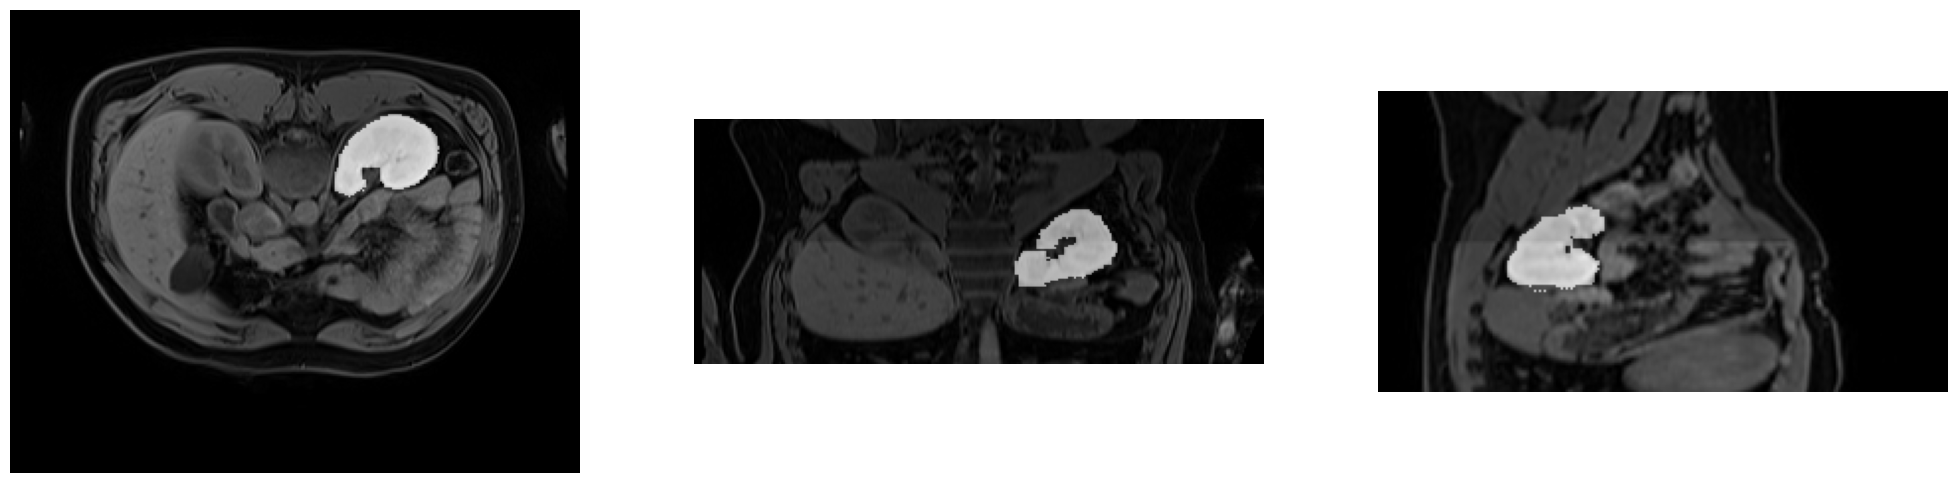

In [7]:
# plot
fig, axs  = plt.subplots(1,3, figsize=(25, 25))

axs[2].imshow(img_array[ :, :, 188], cmap='gray')
axs[2].imshow(ori_zeros[:, :, 188], cmap='gray', alpha=0.5)
axs[2].axis('off')

axs[1].imshow(img_array[:,80,:], cmap='gray')
axs[1].imshow(ori_zeros[:, 80, :], cmap='gray', alpha=0.5)
axs[1].axis('off')

axs[0].imshow(img_array[68, :,:], cmap='gray')
axs[0].imshow(ori_zeros[ 68, :, :], cmap='gray', alpha=0.5)
axs[0].axis('off')
plt.show()

In [ ]:
# eval on test set

num_epochs = 150
ckp_paths = sorted(glob(os.path.join(save_path_ckp, f'epochs{num_epochs}', '*latest.pth')))
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))
dice_test = []

# wandb
wandb.init(
    # Set the project where this run will be logged
    project="SAM-Activelearning", 
    group="random",
    name=f'{base_model}_{sam_model_type}_{task}_{strategy}_epoch{num_epochs}',
    config = {
        "task": task,
        'label_id': label_id,
        'base_model': base_model,
        "model": sam_model_type,
        "strategy": strategy,
        "num_epochs": num_epochs
    }
)
table = wandb.Table(columns=["image", "pred", "gt", 'id', 'dice'])

# eval on test set for each checkpoint
for p in tqdm(ckp_paths):
    avg_dice = []
    for t in tqdm(testing_pool):
        id = os.path.basename(t).split('.')[0]
        imgs = np.load(t)['imgs']

        dataset = NpzDataset([t])
        batch_size = len(dataset)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
        for embeddings, gts, _ in dataloader:
            preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
        gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
        dice = compute_dice_coefficient(gts, preds)
        avg_dice.append(dice)
        if '40' in p:
            preds_int = preds * 1 # convert boolean to int
            log_image_table(imgs, preds_int, gts, id, dice, table)
    dice_test.append(np.mean(avg_dice))
    wandb.log({f"Eval/Dice {strategy} epoch{num_epochs}": np.mean(avg_dice)}, commit=True)
wandb.log({f"predictions_table {strategy} epoch{num_epochs}":table}, commit=True)
wandb.finish()
    

In [ ]:
plt.plot(dice_test)
plt.xlabel('Number of samples')
plt.ylabel('Dice coefficient')
plt.title(f'{base_model} {task} {strategy} sampling')
plt.show()
plt.savefig(os.path.join('figures/eval', f'{base_model}_{task}_{strategy}_epochs{num_epochs}_sampling.png'))
plt.close()

In [ ]:
# testing whole image bbox for original SAM
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))

p = 'checkpoints/SAM/sam_vit_b_01ec64.pth'
for t in tqdm(testing_pool):
    id = os.path.basename(t).split('.')[0]
    imgs = np.load(t)['imgs']

    dataset = NpzDataset([t])
    batch_size = len(dataset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
    for embeddings, gts, _ in dataloader:
        preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
    # print(preds.shape, type(preds))

    gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
    # print(gts.shape, type(gts))  
    dice = compute_dice_coefficient(gts, preds)
    avg_dice.append(dice)

In [ ]:
# testing whole image bbox for MedSAM
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))

p = 'checkpoints/MedSAM/medsam_20230423_vit_b_0.0.1.pth'
for t in tqdm(testing_pool):
    id = os.path.basename(t).split('.')[0]
    imgs = np.load(t)['imgs']

    dataset = NpzDataset([t])
    batch_size = len(dataset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
    for embeddings, gts, _ in dataloader:
        preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
    # print(preds.shape, type(preds))

    gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
    # print(gts.shape, type(gts))  
    dice = compute_dice_coefficient(gts, preds)
    avg_dice.append(dice)
print(avg_dice)
print(np.mean(avg_dice))